### Imports & Setup

In [3]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

DATA_PATH = "Tofinal/final_personal_finance_dataset_v2.csv"
MODEL_DIR = "models"
OUT_DIR = "outputs"

os.makedirs(OUT_DIR, exist_ok=True)

print("[OK] Notebook 03 setup complete.")

[OK] Notebook 03 setup complete.


In [4]:
dtype_map = {
    "Transaction Description": "string",
    "Category": "string",
    "Type": "string",
    "UserID": "string",
    "TransactionID": "string",
    "Currency": "string",
    "Merchant": "string",
    "Account Name": "string",
    "SourceDataset": "string",
    "UnifiedCategory": "string",
}

df = pd.read_csv(DATA_PATH, dtype=dtype_map)
print(f"[INFO] Loaded rows={len(df):,}, cols={len(df.columns)}")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date", "Amount"]).reset_index(drop=True)

# Ensure numeric amount
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
df = df.dropna(subset=["Amount"]).reset_index(drop=True)

# Standardize Type
df["Type"] = df["Type"].fillna("").astype(str).str.title()
df.loc[~df["Type"].isin(["Expense", "Income", "Transfer"]), "Type"] = "Other"

# YearMonth for monthly analysis
df["YearMonth"] = df["Date"].dt.to_period("M")

print("[INFO] Cleaned:", df.shape)
df.head(3)

[INFO] Loaded rows=1,044,771, cols=12
[INFO] Cleaned: (1044771, 13)


,Date,Transaction Description,Category,Amount,Type,UserID,TransactionID,Currency,Merchant,Account Name,SourceDataset,UnifiedCategory,YearMonth
0,2016-04-13,Bought vegetables and fruits,Groceries,9.40,Expense,US8055,TRX8_227498,<NA>,<NA>,<NA>,unknown_transactions,Other,2016-04
1,2019-01-02,Fuel purchase at local station,Motor/Travel,60.97,Expense,US8186,TRX8_759940,<NA>,<NA>,<NA>,unknown_transactions,Transport,2019-01
2,2013-11-04,Parking fee,Motor/Travel,223.55,Expense,US8114,TRX8_474070,<NA>,<NA>,<NA>,unknown_transactions,Transport,2013-11


### Ensure ClusterID exists

In [5]:
CLUSTERED_PARQUET = os.path.join(OUT_DIR, "df_clustered.parquet")
CLUSTERED_CSV = os.path.join(OUT_DIR, "df_clustered.csv")

if os.path.exists(CLUSTERED_PARQUET):
    df = pd.read_parquet(CLUSTERED_PARQUET)
    print("[OK] Loaded pre-clustered dataset:", df.shape)

elif os.path.exists(CLUSTERED_CSV):
    df = pd.read_csv(CLUSTERED_CSV, dtype=dtype_map)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["YearMonth"] = pd.to_datetime(df["Date"], errors="coerce").dt.to_period("M")
    df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
    print("[OK] Loaded pre-clustered dataset:", df.shape)

else:
    print("[WARN] No clustered dataset found in outputs/.")
    print("      If df does not contain ClusterID, do NOT recompute SBERT here (too slow).")
    print("      For MVP: you can skip Cluster usage in behavior layer OR process only a sample/user subset.")

print("Columns now:", df.columns.tolist())

[WARN] No clustered dataset found in outputs/.
      If df does not contain ClusterID, do NOT recompute SBERT here (too slow).
      For MVP: you can skip Cluster usage in behavior layer OR process only a sample/user subset.
Columns now: ['Date', 'Transaction Description', 'Category', 'Amount', 'Type', 'UserID', 'TransactionID', 'Currency', 'Merchant', 'Account Name', 'SourceDataset', 'UnifiedCategory', 'YearMonth']


### Build CanonicalMerchant if missing

In [6]:
if "CanonicalMerchant" not in df.columns:
    if "ClusterID" in df.columns:
        cluster_exemplars = (
            df.groupby("ClusterID")["Merchant"]
              .agg(lambda x: x.value_counts().index[0] if x.notna().any() else "Unknown")
              .to_dict()
        )
        df["CanonicalMerchant"] = df["ClusterID"].map(cluster_exemplars)
        print("[OK] CanonicalMerchant created from ClusterID.")
    else:
        df["CanonicalMerchant"] = df["Merchant"].fillna("Unknown")
        print("[WARN] No ClusterID → CanonicalMerchant fallback = Merchant.")

[WARN] No ClusterID → CanonicalMerchant fallback = Merchant.


### Behavior Layer — Monthly Aggregates

In [7]:
monthly = (
    df.groupby(["UserID", "YearMonth", "Type"])["Amount"]
      .sum()
      .unstack(fill_value=0)
      .reset_index()
)

# Ensure columns exist
for col in ["Expense", "Income"]:
    if col not in monthly.columns:
        monthly[col] = 0.0

# Add total
monthly["Net"] = monthly["Income"] - monthly["Expense"]

print("[INFO] Monthly table:", monthly.shape)
monthly.head()

[INFO] Monthly table: (13886, 5)


Type,UserID,YearMonth,Expense,Income,Net
0,US001,2020-01,16061.16,6655.09,-9406.07
1,US001,2020-02,16814.10,20364.31,3550.21
2,US001,2020-03,13581.81,3465.00,-10116.81
3,US001,2020-04,14010.45,9592.60,-4417.85
4,US001,2020-05,16528.08,6326.05,-10202.03


### Core Behavior Features Per User

In [8]:
user_avg = (
    monthly.groupby("UserID")[["Expense", "Income", "Net"]]
           .mean()
           .rename(columns={
               "Expense": "AvgMonthlyExpense",
               "Income": "AvgMonthlyIncome",
               "Net": "AvgMonthlyNet"
           })
           .reset_index()
)

# (B) Spending volatility (CV = std/mean of monthly expenses)
tmp = monthly.groupby("UserID")["Expense"]
user_vol = (
    pd.DataFrame({
        "UserID": tmp.mean().index,
        "SpendingVolatility": (tmp.std(ddof=0) / (tmp.mean() + 1e-6)).values
    })
)

# (C) Overspending flag based on averages (MVP simple)
feat_df = user_avg.merge(user_vol, on="UserID", how="left").fillna(0.0)

feat_df["Overspending"] = feat_df["AvgMonthlyExpense"] > feat_df["AvgMonthlyIncome"]

feat_df.head()

,UserID,AvgMonthlyExpense,AvgMonthlyIncome,AvgMonthlyNet,SpendingVolatility,Overspending
0,US001,17969.013667,14719.009167,-3250.004500,0.257605,True
1,US008,9675.936923,0.000000,-9675.936923,0.302381,True
2,US009,81444.809556,67608.296667,-13836.512889,1.245323,True
3,US8001,2172.409118,0.000000,-2172.409118,0.244224,True
4,US8002,7823.932581,0.000000,-7823.932581,0.236581,True


### Subscription Creep (Recurring Merchant ≥ 3 months)

In [9]:
exp = df[df["Type"] == "Expense"].copy()

# Use CanonicalMerchant if available for cleaner recurring detection
merchant_col = "CanonicalMerchant" if "CanonicalMerchant" in exp.columns else "Merchant"
exp[merchant_col] = exp[merchant_col].fillna("Unknown").astype(str)

# Count distinct months per (UserID, merchant)
subs_count = (
    exp.groupby(["UserID", merchant_col])["YearMonth"]
       .nunique()
       .reset_index(name="ActiveMonths")
)

# merchants active >= 3 months
subs_active = subs_count[subs_count["ActiveMonths"] >= 3]

# subscription count per user
subs_user = (
    subs_active.groupby("UserID")
              .size()
              .reset_index(name="SubscriptionCount")
)

feat_df = feat_df.merge(subs_user, on="UserID", how="left").fillna({"SubscriptionCount": 0})
feat_df["SubscriptionCreep"] = feat_df["SubscriptionCount"] > 5

feat_df.head()

,UserID,AvgMonthlyExpense,AvgMonthlyIncome,AvgMonthlyNet,SpendingVolatility,Overspending,SubscriptionCount,SubscriptionCreep
0,US001,17969.013667,14719.009167,-3250.004500,0.257605,True,20,True
1,US008,9675.936923,0.000000,-9675.936923,0.302381,True,19,True
2,US009,81444.809556,67608.296667,-13836.512889,1.245323,True,65,True
3,US8001,2172.409118,0.000000,-2172.409118,0.244224,True,1,False
4,US8002,7823.932581,0.000000,-7823.932581,0.236581,True,1,False


### Micro-Spending (last 30 days, expenses < threshold)

In [10]:
MICRO_THRESHOLD = 10.0
WINDOW_DAYS = 30

# For each user, compute based on their latest date.
# To keep it fast, we do it with groupby apply but only on necessary columns.
df_small = df[["UserID", "Date", "Type", "Amount"]].copy()

def micro_spend_count(user_df):
    user_df = user_df.sort_values("Date")
    end = user_df["Date"].max()
    start = end - pd.Timedelta(days=WINDOW_DAYS)
    mask = (
        (user_df["Type"] == "Expense") &
        (user_df["Date"].between(start, end)) &
        (user_df["Amount"] < MICRO_THRESHOLD)
    )
    return int(mask.sum())

micro_counts = (
    df_small.groupby("UserID", group_keys=False)
            .apply(micro_spend_count)
            .reset_index(name="MicroCount30D")
)

feat_df = feat_df.merge(micro_counts, on="UserID", how="left").fillna({"MicroCount30D": 0})
feat_df["MicroSpender"] = feat_df["MicroCount30D"] > 20

feat_df.head()

C:\Users\Geemeth\AppData\Local\Temp\ipykernel_26812\3236795267.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(micro_spend_count)


,UserID,AvgMonthlyExpense,AvgMonthlyIncome,AvgMonthlyNet,SpendingVolatility,Overspending,SubscriptionCount,SubscriptionCreep,MicroCount30D,MicroSpender
0,US001,17969.013667,14719.009167,-3250.004500,0.257605,True,20,True,0,False
1,US008,9675.936923,0.000000,-9675.936923,0.302381,True,19,True,2,False
2,US009,81444.809556,67608.296667,-13836.512889,1.245323,True,65,True,0,False
3,US8001,2172.409118,0.000000,-2172.409118,0.244224,True,1,False,33,True
4,US8002,7823.932581,0.000000,-7823.932581,0.236581,True,1,False,0,False


### Payday Spike Ratio (7 days after last income)

In [11]:
df_pay = df[["UserID", "Date", "YearMonth", "Type", "Amount"]].copy()

def payday_ratio(user_df):
    user_df = user_df.sort_values("Date")

    inc = user_df[user_df["Type"] == "Income"]
    expu = user_df[user_df["Type"] == "Expense"]
    if inc.empty or expu.empty:
        return 0.0

    last_income_date = inc["Date"].max()
    if pd.isna(last_income_date):
        return 0.0

    window_end = last_income_date + pd.Timedelta(days=7)
    post_pay = expu[(expu["Date"] >= last_income_date) & (expu["Date"] <= window_end)]["Amount"].sum()

    month_period = last_income_date.to_period("M")
    month_total = expu[expu["YearMonth"] == month_period]["Amount"].sum()

    if month_total <= 0:
        return 0.0
    return float(post_pay / month_total)

pay_ratio = (
    df_pay.groupby("UserID", group_keys=False)
          .apply(payday_ratio)
          .reset_index(name="PaydaySpikeRatio")
)

feat_df = feat_df.merge(pay_ratio, on="UserID", how="left").fillna({"PaydaySpikeRatio": 0.0})
feat_df["PresentBias"] = feat_df["PaydaySpikeRatio"] > 0.5

feat_df.head()

C:\Users\Geemeth\AppData\Local\Temp\ipykernel_26812\2984523722.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(payday_ratio)


,UserID,AvgMonthlyExpense,AvgMonthlyIncome,AvgMonthlyNet,SpendingVolatility,Overspending,SubscriptionCount,SubscriptionCreep,MicroCount30D,MicroSpender,PaydaySpikeRatio,PresentBias
0,US001,17969.013667,14719.009167,-3250.004500,0.257605,True,20,True,0,False,0.06458,False
1,US008,9675.936923,0.000000,-9675.936923,0.302381,True,19,True,2,False,0.00000,False
2,US009,81444.809556,67608.296667,-13836.512889,1.245323,True,65,True,0,False,1.00000,True
3,US8001,2172.409118,0.000000,-2172.409118,0.244224,True,1,False,33,True,0.00000,False
4,US8002,7823.932581,0.000000,-7823.932581,0.236581,True,1,False,0,False,0.00000,False


### Mental Accounting (Top category share in latest month)

In [12]:
cat_col = "UnifiedCategory" if "UnifiedCategory" in df.columns else "Category"
df_cat = df[["UserID", "YearMonth", "Type", "Amount", cat_col]].copy()
df_cat[cat_col] = df_cat[cat_col].fillna("Other").astype(str)

def top_category_share(user_df):
    latest = user_df["YearMonth"].max()
    expu = user_df[(user_df["Type"] == "Expense") & (user_df["YearMonth"] == latest)]
    if expu.empty:
        return 0.0
    by_cat = expu.groupby(cat_col)["Amount"].sum()
    total = by_cat.sum()
    if total <= 0:
        return 0.0
    return float((by_cat / total).max())

top_share = (
    df_cat.groupby("UserID", group_keys=False)
          .apply(top_category_share)
          .reset_index(name="TopCategoryShare")
)

feat_df = feat_df.merge(top_share, on="UserID", how="left").fillna({"TopCategoryShare": 0.0})
feat_df["MentalAccounting"] = feat_df["TopCategoryShare"] > 0.4

feat_df.head()


C:\Users\Geemeth\AppData\Local\Temp\ipykernel_26812\81582287.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(top_category_share)


,UserID,AvgMonthlyExpense,AvgMonthlyIncome,AvgMonthlyNet,SpendingVolatility,Overspending,SubscriptionCount,SubscriptionCreep,MicroCount30D,MicroSpender,PaydaySpikeRatio,PresentBias,TopCategoryShare,MentalAccounting
0,US001,17969.013667,14719.009167,-3250.004500,0.257605,True,20,True,0,False,0.06458,False,0.453152,True
1,US008,9675.936923,0.000000,-9675.936923,0.302381,True,19,True,2,False,0.00000,False,0.400705,True
2,US009,81444.809556,67608.296667,-13836.512889,1.245323,True,65,True,0,False,1.00000,True,0.447731,True
3,US8001,2172.409118,0.000000,-2172.409118,0.244224,True,1,False,33,True,0.00000,False,0.440373,True
4,US8002,7823.932581,0.000000,-7823.932581,0.236581,True,1,False,0,False,0.00000,False,0.354984,False


### Final Flags Table (Explainable)

In [13]:
feat_df["VolatileSpender"] = feat_df["SpendingVolatility"] > 0.5

flags_df = feat_df[[
    "UserID",
    "PresentBias",
    "MicroSpender",
    "SubscriptionCreep",
    "Overspending",
    "VolatileSpender",
    "MentalAccounting"
]].copy()

print("[INFO] Flags table:")
flags_df.head()

[INFO] Flags table:


,UserID,PresentBias,MicroSpender,SubscriptionCreep,Overspending,VolatileSpender,MentalAccounting
0,US001,False,False,True,True,False,True
1,US008,False,False,True,True,False,True
2,US009,True,False,True,True,True,True
3,US8001,False,True,False,True,False,True
4,US8002,False,False,False,True,False,False


### Insights (Human-readable summaries)

In [14]:
def build_insight_row(row):
    msgs = []
    if row["PresentBias"]:
        msgs.append("Present Bias (high spending immediately after payday)")
    if row["MicroSpender"]:
        msgs.append("Micro-Spending (many small purchases in last 30 days)")
    if row["SubscriptionCreep"]:
        msgs.append("Subscription Creep (many recurring monthly merchants)")
    if row["Overspending"]:
        msgs.append("Overspending (avg expense > avg income)")
    if row["VolatileSpender"]:
        msgs.append("Volatile Spending (high month-to-month variance)")
    if row["MentalAccounting"]:
        msgs.append("Mental Accounting (spending dominated by one category)")
    return " | ".join(msgs) if msgs else "No major risk indicators detected"

insights = flags_df.copy()
insights["InsightSummary"] = flags_df.apply(build_insight_row, axis=1)

insights.head()

,UserID,PresentBias,MicroSpender,SubscriptionCreep,Overspending,VolatileSpender,MentalAccounting,InsightSummary
0,US001,False,False,True,True,False,True,Subscription Creep (many recurring monthly merchants) | Overspending (avg expense > avg income) | Mental Accounting ...
1,US008,False,False,True,True,False,True,Subscription Creep (many recurring monthly merchants) | Overspending (avg expense > avg income) | Mental Accounting ...
2,US009,True,False,True,True,True,True,Present Bias (high spending immediately after payday) | Subscription Creep (many recurring monthly merchants) | Over...
3,US8001,False,True,False,True,False,True,Micro-Spending (many small purchases in last 30 days) | Overspending (avg expense > avg income) | Mental Accounting ...
4,US8002,False,False,False,True,False,False,Overspending (avg expense > avg income)


### Simple Visuals

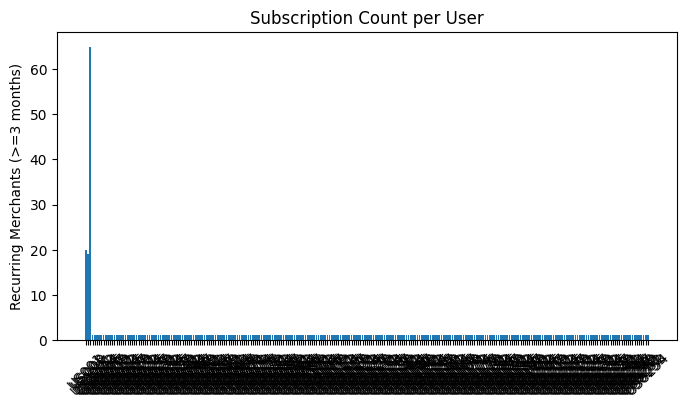

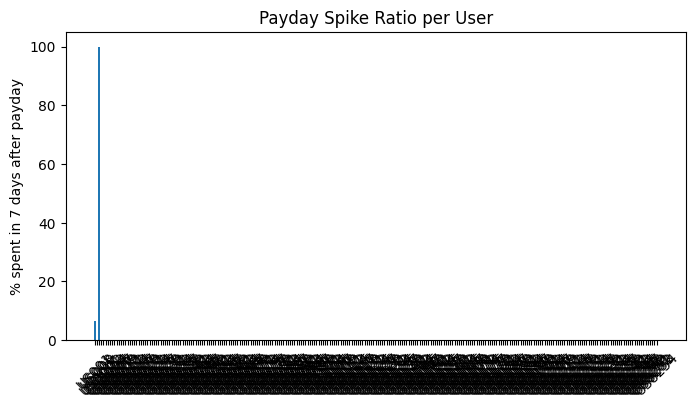

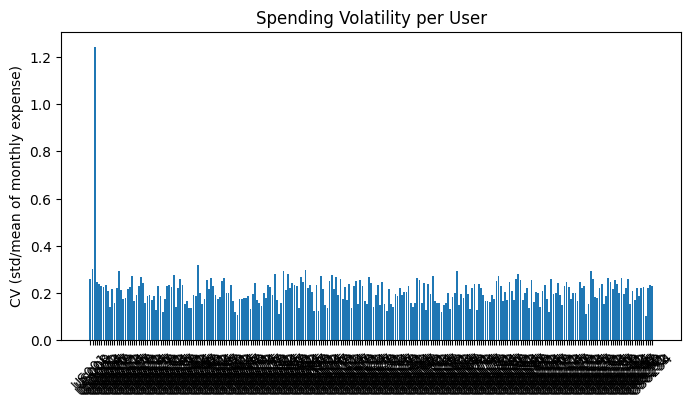

In [15]:
# 1) Subscription counts
plt.figure(figsize=(8,4))
plt.bar(feat_df["UserID"].astype(str), feat_df["SubscriptionCount"])
plt.title("Subscription Count per User")
plt.ylabel("Recurring Merchants (>=3 months)")
plt.xticks(rotation=45)
plt.show()

# 2) Payday spike ratio
plt.figure(figsize=(8,4))
plt.bar(feat_df["UserID"].astype(str), feat_df["PaydaySpikeRatio"] * 100)
plt.title("Payday Spike Ratio per User")
plt.ylabel("% spent in 7 days after payday")
plt.xticks(rotation=45)
plt.show()

# 3) Spending volatility
plt.figure(figsize=(8,4))
plt.bar(feat_df["UserID"].astype(str), feat_df["SpendingVolatility"])
plt.title("Spending Volatility per User")
plt.ylabel("CV (std/mean of monthly expense)")
plt.xticks(rotation=45)
plt.show()

### Save Outputs

In [16]:
feat_path = os.path.join(OUT_DIR, "behavior_features.csv")
flags_path = os.path.join(OUT_DIR, "behavior_flags.csv")
ins_path = os.path.join(OUT_DIR, "behavior_insights.csv")

feat_df.to_csv(feat_path, index=False)
flags_df.to_csv(flags_path, index=False)
insights.to_csv(ins_path, index=False)

print("[OK] Saved:")
print(" -", feat_path)
print(" -", flags_path)
print(" -", ins_path)

[OK] Saved:
 - outputs\behavior_features.csv
 - outputs\behavior_flags.csv
 - outputs\behavior_insights.csv
